In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
plt.style.use('dark_background')
warnings.filterwarnings("ignore")

# **CONSTANT**

In [ ]:
DATA_PATH = '/content/drive/MyDrive/ML Project/DataSet/Original DataSet/train.csv'
ONE_HOT_ENCODE = '/content/onehot_encoder(features).joblib'

#**Read Data**

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.drop(['id','Irrigation_Need'] , axis=1)
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South


In [ ]:
df['Crop_Type'].value_counts()

,count
Crop_Type,
Sugarcane,108910
Rice,106697
Cotton,104645
Maize,104274
Wheat,103005
Potato,102469


In [ ]:
df.shape

(630000, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [ ]:
print('missing value :' , df.isnull().sum().sum())
print('duplicated :' , df.duplicated().sum())

missing value : 0
duplicated : 0


# **Split data to train , test**

In [ ]:
df_train , df_test = train_test_split(df , test_size=0.07 ,
                                      random_state = 42 ,
                                      shuffle=True ,
                                      stratify=df['Crop_Type'])
df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

In [ ]:
# from google.colab import files

# # Save the DataFrame to a CSV file
# df_test.to_csv('test_data(crop_remmendation).csv', index=False)

# # Download the file
# files.download('test_data(crop_remmendation).csv')

In [ ]:
print(f'Shape of training data: {df_train.shape}')
print(f'Shape of testing data: {df_test.shape}')

Shape of training data: (585899, 19)
Shape of testing data: (44101, 19)


Text(0.5, 0, 'Crop_Type')

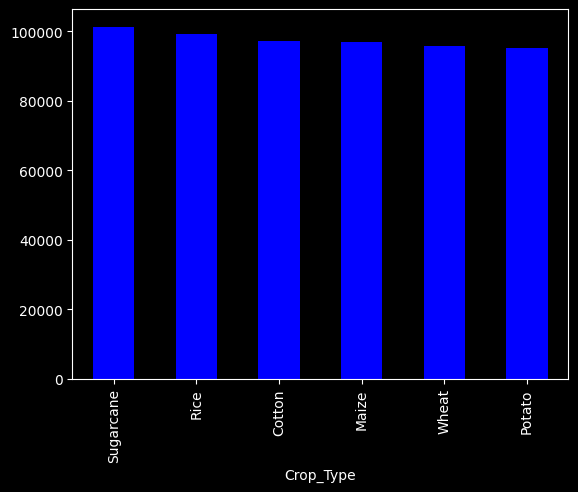

In [ ]:
df_train['Crop_Type'].value_counts().plot(kind = 'bar' , color = 'b'  )
plt.xlabel('Crop_Type' , fontsize = 10)

In [ ]:
df_test['Crop_Type'].value_counts() # test

,count
Crop_Type,
Sugarcane,7624
Rice,7469
Cotton,7325
Maize,7299
Wheat,7211
Potato,7173


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585899 entries, 0 to 585898
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                585899 non-null  object 
 1   Soil_pH                  585899 non-null  float64
 2   Soil_Moisture            585899 non-null  float64
 3   Organic_Carbon           585899 non-null  float64
 4   Electrical_Conductivity  585899 non-null  float64
 5   Temperature_C            585899 non-null  float64
 6   Humidity                 585899 non-null  float64
 7   Rainfall_mm              585899 non-null  float64
 8   Sunlight_Hours           585899 non-null  float64
 9   Wind_Speed_kmh           585899 non-null  float64
 10  Crop_Type                585899 non-null  object 
 11  Crop_Growth_Stage        585899 non-null  object 
 12  Season                   585899 non-null  object 
 13  Irrigation_Type          585899 non-null  object 
 14  Wate

In [ ]:
df_num = df_train.select_dtypes(include = ['int64' , 'float64' ])
df_cat = df_train.select_dtypes(include = ['object'])

df_target = df_cat['Crop_Type']
df_cat = df_cat.drop(['Crop_Type'] , axis = 1)

# **Preprocessing (df_train only)**

## **Outlier**

In [ ]:
df_train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Silt,5.26,25.23,0.85,2.63,12.79,94.49,847.22,10.74,16.37,Rice,Sowing,Zaid,Rainfed,Reservoir,12.06,No,15.39,West
1,Sandy,6.02,47.57,0.73,1.24,32.03,66.88,2044.68,10.16,12.67,Sugarcane,Harvest,Zaid,Drip,River,6.74,Yes,73.49,South
2,Silt,5.88,19.16,1.12,0.99,35.66,31.84,2401.92,8.86,19.06,Rice,Flowering,Rabi,Sprinkler,Rainwater,5.77,No,72.79,North
3,Loamy,6.16,43.50,1.58,2.21,29.54,69.67,1534.82,4.99,18.33,Rice,Harvest,Zaid,Canal,River,12.41,No,102.16,East
4,Loamy,5.66,48.88,1.26,0.97,24.68,68.22,1467.62,6.03,14.92,Wheat,Sowing,Kharif,Drip,Reservoir,9.28,Yes,118.96,South


In [ ]:
df_train.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000,585899.000000
mean,6.483315,37.300106,0.922634,1.744335,26.996355,61.560366,1462.817011,7.512965,10.379223,7.516152,62.306894
std,0.922757,16.377288,0.365781,0.952253,8.623654,19.712375,613.127609,1.999014,5.689143,4.217089,34.250508
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.520000,45.380000,954.860000,5.760000,5.300000,3.880000,33.140000
50%,6.450000,37.750000,0.910000,1.740000,26.960000,61.640000,1468.640000,7.580000,10.500000,7.380000,61.150000
75%,7.270000,51.260000,1.220000,2.580000,34.540000,79.120000,2055.520000,9.240000,15.430000,11.140000,92.680000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


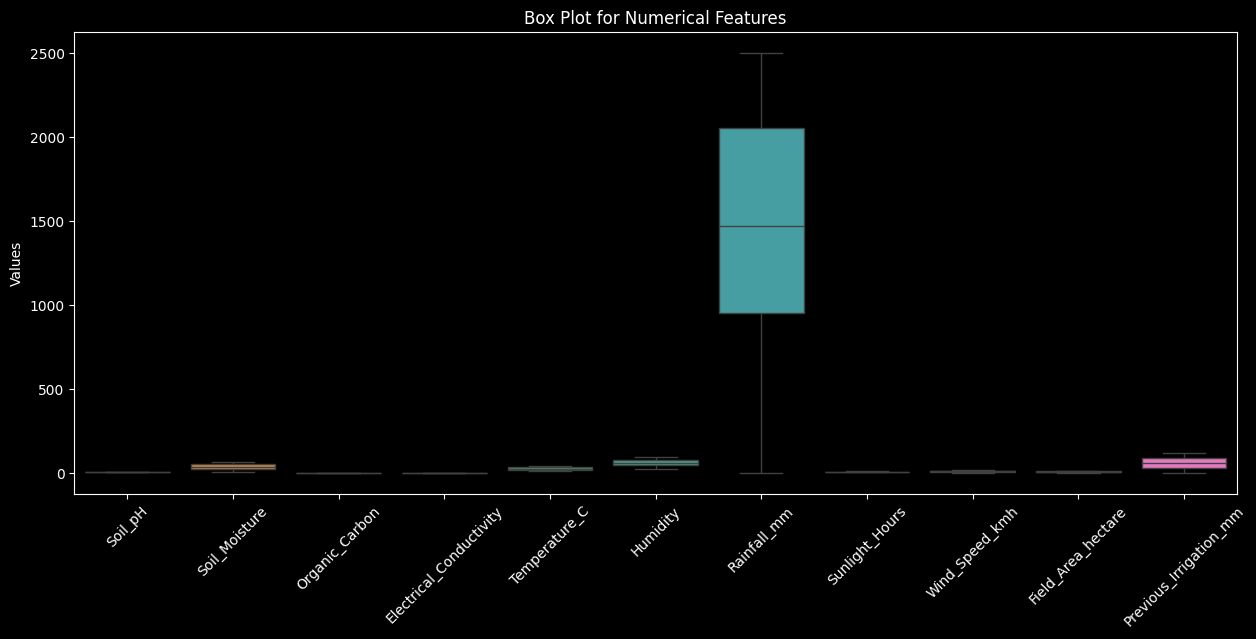

In [ ]:
import seaborn as sns
numeric_cols = df_train.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(15, 6))
sns.boxplot(numeric_cols)
plt.xticks(rotation=45)
plt.title("Box Plot for Numerical Features")
plt.ylabel("Values")
plt.show()

## **Encoder**

In [ ]:
df_cat.head()

,Soil_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
0,Silt,Sowing,Zaid,Rainfed,Reservoir,No,West
1,Sandy,Harvest,Zaid,Drip,River,Yes,South
2,Silt,Flowering,Rabi,Sprinkler,Rainwater,No,North
3,Loamy,Harvest,Zaid,Canal,River,No,East
4,Loamy,Sowing,Kharif,Drip,Reservoir,Yes,South


oneHotEncode for cat feature


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False) # output is dense array

df_cat_encoder_array = encoder.fit_transform(df_cat)
df_encoder_dataFrame = pd.DataFrame(df_cat_encoder_array , columns = encoder.get_feature_names_out(df_cat.columns))

features = pd.concat(
    [df_num, df_encoder_dataFrame],
    axis=1
)

In [ ]:
features.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Crop_Growth_Stage_Flowering,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.26,25.23,0.85,2.63,12.79,94.49,847.22,10.74,16.37,12.06,15.39,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.02,47.57,0.73,1.24,32.03,66.88,2044.68,10.16,12.67,6.74,73.49,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,5.88,19.16,1.12,0.99,35.66,31.84,2401.92,8.86,19.06,5.77,72.79,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6.16,43.50,1.58,2.21,29.54,69.67,1534.82,4.99,18.33,12.41,102.16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.66,48.88,1.26,0.97,24.68,68.22,1467.62,6.03,14.92,9.28,118.96,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


**Label encode for target**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_target.head()

,Crop_Type
0,Rice
1,Sugarcane
2,Rice
3,Rice
4,Wheat


In [ ]:
from sklearn.preprocessing import LabelEncoder
LabelEncode = LabelEncoder()

target = LabelEncode.fit_transform(df_target)

In [ ]:
label_mapping = dict ( zip( LabelEncode.classes_ , LabelEncode.transform(LabelEncode.classes_) ) )
label_mapping # importat

{'Cotton': np.int64(0),
 'Maize': np.int64(1),
 'Potato': np.int64(2),
 'Rice': np.int64(3),
 'Sugarcane': np.int64(4),
 'Wheat': np.int64(5)}

In [ ]:
import joblib
from google.colab import files

# Define the filename for saving the encoder
encoder_filename = 'onehot_encoder(features).joblib'

# Save the fitted encoder
joblib.dump(encoder, encoder_filename)

print(f"OneHotEncoder saved successfully to {encoder_filename}")

# Download the saved encoder file
files.download('onehot_encoder(features).joblib')




# Define the filename for saving the encoder
encoder_filename = 'label_encoder(target).joblib'

# Save the fitted encoder
joblib.dump(LabelEncode, encoder_filename)

print(f"LabelEncoder saved successfully to {encoder_filename}")

# Download the saved encoder file
files.download('label_encoder(target).joblib')

OneHotEncoder saved successfully to onehot_encoder(features).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LabelEncoder saved successfully to label_encoder(target).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Feature Engineering**

### **Feature Extraction**

`Note : We Note Use this feature extraction`

In [ ]:
features.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Crop_Growth_Stage_Flowering,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.26,25.23,0.85,2.63,12.79,94.49,847.22,10.74,16.37,12.06,15.39,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.02,47.57,0.73,1.24,32.03,66.88,2044.68,10.16,12.67,6.74,73.49,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,5.88,19.16,1.12,0.99,35.66,31.84,2401.92,8.86,19.06,5.77,72.79,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6.16,43.50,1.58,2.21,29.54,69.67,1534.82,4.99,18.33,12.41,102.16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.66,48.88,1.26,0.97,24.68,68.22,1467.62,6.03,14.92,9.28,118.96,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
features.columns

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
       'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Crop_Growth_Stage_Flowering',
       'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing',
       'Crop_Growth_Stage_Vegetative', 'Season_Kharif', 'Season_Rabi',
       'Season_Zaid', 'Irrigation_Type_Canal', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Groundwater', 'Water_Source_Rainwater',
       'Water_Source_Reservoir', 'Water_Source_River', 'Mulching_Used_No',
       'Mulching_Used_Yes', 'Region_Central', 'Region_East', 'Region_North',
       'Region_South', 'Region_West'],
      dtype='object')



**1️⃣ First: what matters for crop recommendation**

Crop type depends mainly on:

* **Soil fertility & chemistry** (NPK, pH, EC, Organic Carbon)
* **Water availability** (rainfall, moisture, humidity)
* **Climate & energy** (temperature, sunlight)
* **Geography** (altitude)
* **Management** (fertilizer used)

---

 2️⃣ **High-value feature extraction (recommended)**

 A) Nutrient features (VERY important)

```text
NPK_sum = N + P + K
N_to_P = N / (P + 1)
N_to_K = N / (K + 1)
P_to_K = P / (K + 1)
NPK_balance = max(N,P,K) - min(N,P,K)
```

📌 Crops care more about **balance** than absolute numbers.

---

 B) **Soil chemistry**

```text
pH_distance = |Soil_pH - 7|
EC_log = log(1 + Electrical_Conductivity)
Fertility_index = Organic_Carbon × NPK_sum
```

📌 Many crops have **tight pH ranges**.

---

 C) **Water & climate interactions**

```text
Moisture_Rain = Soil_Moisture × Rainfall
Temp_Humidity = Temperature × Humidity
Heat_Load = Temperature × Sunlight_Hours
Dryness_Index = Temperature / (Humidity + 1)
```

📌 These interactions often outperform raw features.

---

 D) **Geography**

```text
Altitude_Temp = Altitude × Temperature
```

---

 E) **Fertilizer handling**

* If **categorical** → One-Hot Encode
* If **numeric**:

```text
Fert_NPK_interaction = Fertilizer_Used × NPK_sum
```

---

In [ ]:
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered (extracted) features for crop-type recommendation.
    Adjusted for available columns in the current dataset.
    """
    X = df.copy()
    eps = 1e-9  # to avoid divide-by-zero

    # --- Nutrient (NPK) features ---
    # Original dataset does not contain 'N', 'P', 'K' columns.
    # Skipping NPK-related feature engineering.

    # --- Soil chemistry features ---
    if "Soil_pH" in X.columns:
        X["pH_distance"] = (X["Soil_pH"] - 7.0).abs()
    if "Electrical_Conductivity" in X.columns:
        X["EC_log"] = np.log1p(X["Electrical_Conductivity"].clip(lower=0))

    # organic carbon context - since NPK_sum is not available, skipping these
    # X["Fertility_index"] = X["Organic_Carbon"] * (X["NPK_sum"] + eps)
    # X["OC_to_NPK"] = X["Organic_Carbon"] / (X["NPK_sum"] + 1.0)

    # --- Water / climate interaction features ---
    if "Soil_Moisture" in X.columns and "Rainfall_mm" in X.columns:
        X["Moisture_Rain"] = X["Soil_Moisture"] * X["Rainfall_mm"]
    if "Temperature_C" in X.columns and "Humidity" in X.columns:
        X["Temp_Humidity"] = X["Temperature_C"] * X["Humidity"]
    if "Temperature_C" in X.columns and "Sunlight_Hours" in X.columns:
        X["Heat_Load"] = X["Temperature_C"] * X["Sunlight_Hours"]
    if "Sunlight_Hours" in X.columns and "Rainfall_mm" in X.columns:
        X["SunRain_ratio"] = X["Sunlight_Hours"] / (X["Rainfall_mm"] + 1.0)
    if "Temperature_C" in X.columns and "Humidity" in X.columns:
        X["Dryness_Index"] = X["Temperature_C"] / (X["Humidity"] + 1.0)

    # --- Geography interaction ---
    # 'Altitude' column is not present in the dataset. Skipping.
    # X["Altitude_Temp"] = X["Altitude"] * X["Temperature"]

    # --- Fertilizer interaction ---
    # 'Fertilizer_Used' column is not present. Skipping.
    # if "Fertilizer_Used" in X.columns and pd.api.types.is_numeric_dtype(X["Fertilizer_Used"]):
    #     X["Fert_NPK_interaction"] = X["Fertilizer_Used"] * (X["NPK_sum"] + eps)

    return X

In [ ]:
feature_with_extract = features

In [ ]:
feature_with_extract.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Crop_Growth_Stage_Flowering,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.26,25.23,0.85,2.63,12.79,94.49,847.22,10.74,16.37,12.06,15.39,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.02,47.57,0.73,1.24,32.03,66.88,2044.68,10.16,12.67,6.74,73.49,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,5.88,19.16,1.12,0.99,35.66,31.84,2401.92,8.86,19.06,5.77,72.79,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6.16,43.50,1.58,2.21,29.54,69.67,1534.82,4.99,18.33,12.41,102.16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.66,48.88,1.26,0.97,24.68,68.22,1467.62,6.03,14.92,9.28,118.96,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
feature_with_extract.shape

(585899, 37)

###**Feature Selection**

In [ ]:
print(feature_with_extract.shape)

(585899, 37)


In [ ]:
feature_with_extract.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Crop_Growth_Stage_Flowering,Crop_Growth_Stage_Harvest,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.26,25.23,0.85,2.63,12.79,94.49,847.22,10.74,16.37,12.06,15.39,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.02,47.57,0.73,1.24,32.03,66.88,2044.68,10.16,12.67,6.74,73.49,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,5.88,19.16,1.12,0.99,35.66,31.84,2401.92,8.86,19.06,5.77,72.79,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6.16,43.50,1.58,2.21,29.54,69.67,1534.82,4.99,18.33,12.41,102.16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.66,48.88,1.26,0.97,24.68,68.22,1467.62,6.03,14.92,9.28,118.96,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.feature_selection import mutual_info_classif

discrete_mask = [
    (feature_with_extract[col].nunique() <= 10)
    for col in feature_with_extract.columns
]


MI = mutual_info_classif(feature_with_extract , target , discrete_features = discrete_mask , random_state=42)

MI = pd.DataFrame({'features' :feature_with_extract.columns , 'mi':MI}).sort_values(['mi'] , ascending=False).reset_index(drop= True)
# features With Target
print('MI DF shape : ' ,MI.shape)

MI DF shape :  (37, 2)


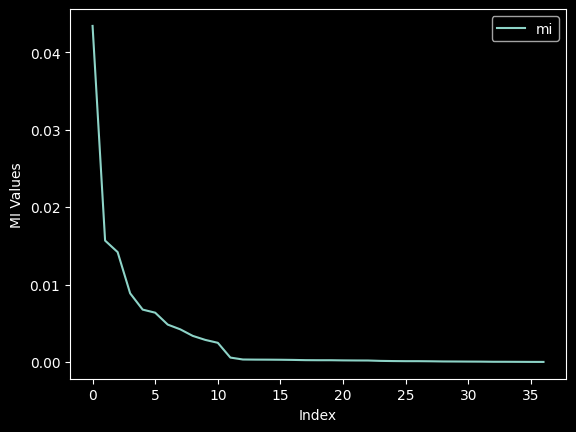

In [ ]:
MI.plot()
plt.xlabel('Index')
plt.ylabel('MI Values')
plt.show()

`We take only 14 features`

In [ ]:
MI = MI[1:15]

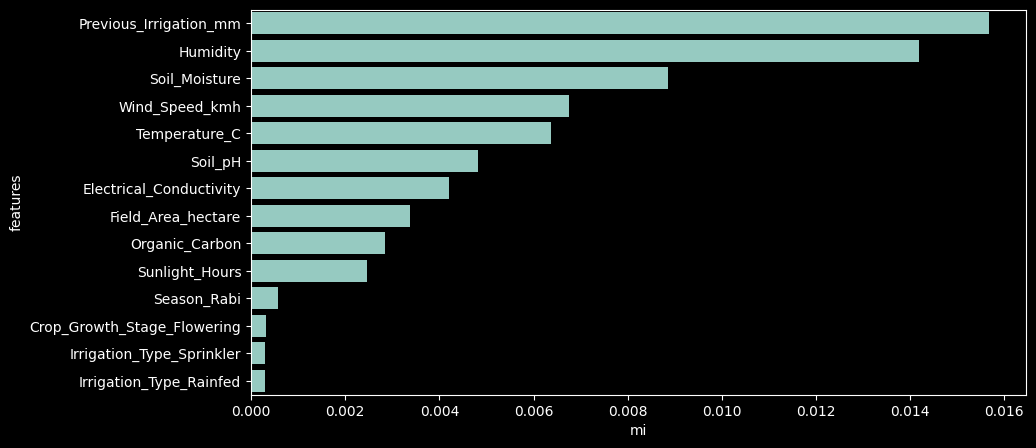

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(MI, x="mi", y="features" , )
plt.show()

In [ ]:
MI_columns = MI.features.tolist()
len (MI_columns)

14

In [ ]:
features_after_FS = feature_with_extract[MI_columns]
features_after_FS.head()

,Previous_Irrigation_mm,Humidity,Soil_Moisture,Wind_Speed_kmh,Temperature_C,Soil_pH,Electrical_Conductivity,Field_Area_hectare,Organic_Carbon,Sunlight_Hours,Season_Rabi,Crop_Growth_Stage_Flowering,Irrigation_Type_Sprinkler,Irrigation_Type_Rainfed
0,15.39,94.49,25.23,16.37,12.79,5.26,2.63,12.06,0.85,10.74,0.0,0.0,0.0,1.0
1,73.49,66.88,47.57,12.67,32.03,6.02,1.24,6.74,0.73,10.16,0.0,0.0,0.0,0.0
2,72.79,31.84,19.16,19.06,35.66,5.88,0.99,5.77,1.12,8.86,1.0,1.0,1.0,0.0
3,102.16,69.67,43.50,18.33,29.54,6.16,2.21,12.41,1.58,4.99,0.0,0.0,0.0,0.0
4,118.96,68.22,48.88,14.92,24.68,5.66,0.97,9.28,1.26,6.03,0.0,0.0,0.0,0.0


In [ ]:
print(features_after_FS.shape)

(585899, 14)


**for pipeline**

In [ ]:
features_after_FS.columns

Index(['Previous_Irrigation_mm', 'Humidity', 'Soil_Moisture', 'Wind_Speed_kmh',
       'Temperature_C', 'Soil_pH', 'Electrical_Conductivity',
       'Field_Area_hectare', 'Organic_Carbon', 'Sunlight_Hours', 'Season_Rabi',
       'Crop_Growth_Stage_Flowering', 'Irrigation_Type_Sprinkler',
       'Irrigation_Type_Rainfed'],
      dtype='object')

In [ ]:
def feature_selection(feature_with_extract: pd.DataFrame) -> pd.DataFrame:
  x = feature_with_extract[['Previous_Irrigation_mm', 'Humidity', 'Soil_Moisture', 'Wind_Speed_kmh',
       'Temperature_C', 'Soil_pH', 'Electrical_Conductivity',
       'Field_Area_hectare', 'Organic_Carbon', 'Sunlight_Hours', 'Season_Rabi',
       'Crop_Growth_Stage_Flowering', 'Irrigation_Type_Sprinkler',
       'Irrigation_Type_Rainfed']]
  return x

In [ ]:
x = feature_selection(feature_with_extract)
x.head()

,Previous_Irrigation_mm,Humidity,Soil_Moisture,Wind_Speed_kmh,Temperature_C,Soil_pH,Electrical_Conductivity,Field_Area_hectare,Organic_Carbon,Sunlight_Hours,Season_Rabi,Crop_Growth_Stage_Flowering,Irrigation_Type_Sprinkler,Irrigation_Type_Rainfed
0,15.39,94.49,25.23,16.37,12.79,5.26,2.63,12.06,0.85,10.74,0.0,0.0,0.0,1.0
1,73.49,66.88,47.57,12.67,32.03,6.02,1.24,6.74,0.73,10.16,0.0,0.0,0.0,0.0
2,72.79,31.84,19.16,19.06,35.66,5.88,0.99,5.77,1.12,8.86,1.0,1.0,1.0,0.0
3,102.16,69.67,43.50,18.33,29.54,6.16,2.21,12.41,1.58,4.99,0.0,0.0,0.0,0.0
4,118.96,68.22,48.88,14.92,24.68,5.66,0.97,9.28,1.26,6.03,0.0,0.0,0.0,0.0


### **Transformation**

In [ ]:
len(features_after_FS.columns)

14

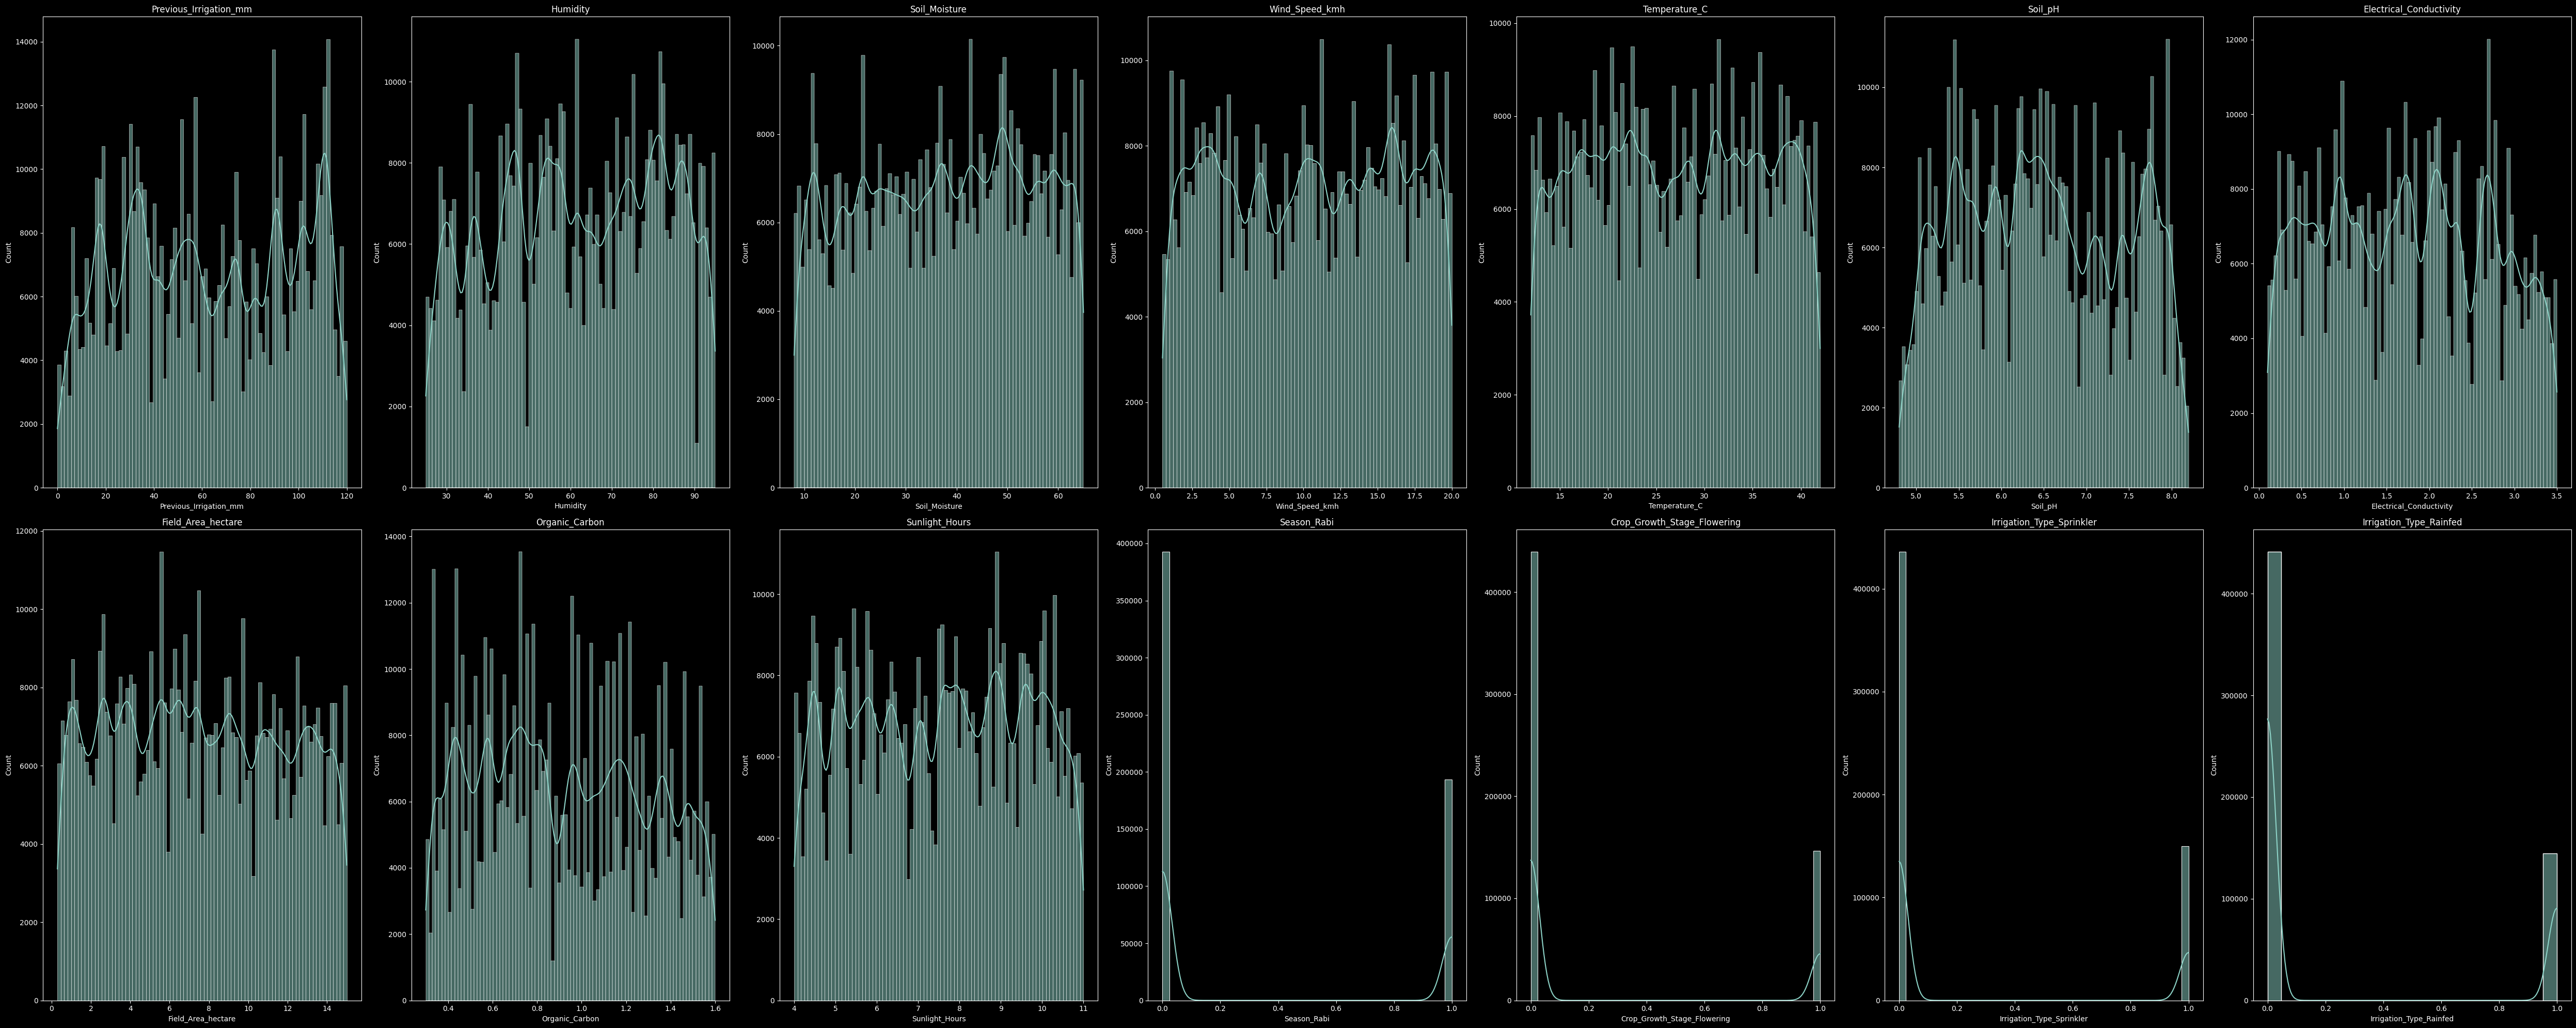

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(50, 20))
axes = axes.flatten()

for i, col in enumerate(features_after_FS.columns):
    sns.histplot(
        features_after_FS[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
X_gaussian = pt.fit_transform(features_after_FS)

X_gaussian = pd.DataFrame(
    X_gaussian,
    columns=features_after_FS.columns
)

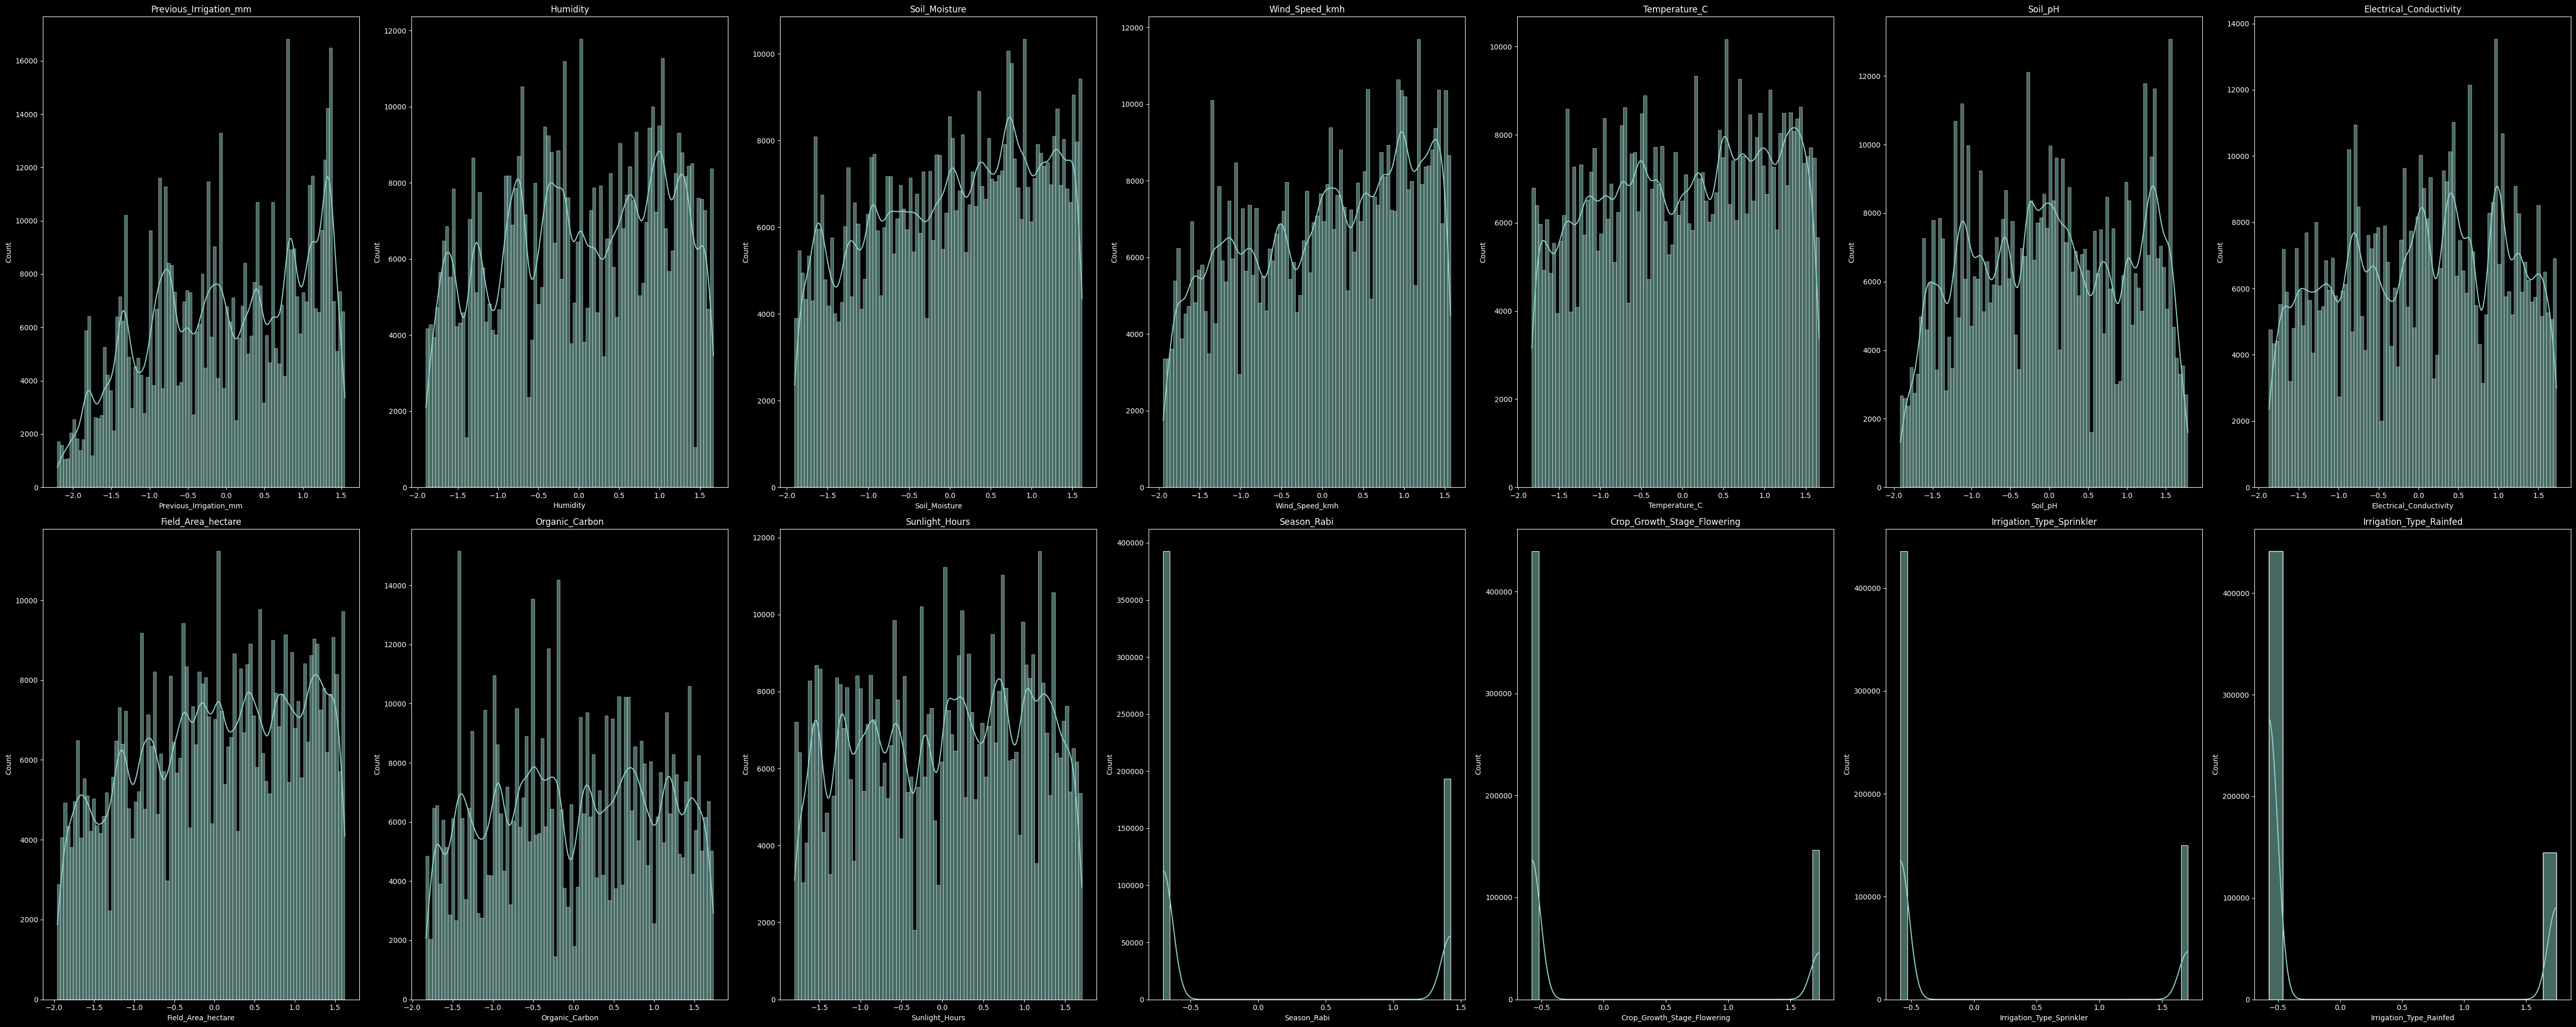

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(50, 20))
axes = axes.flatten()

for i, col in enumerate(X_gaussian.columns):
    sns.histplot(
        X_gaussian[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
X_gaussian.head()

,Previous_Irrigation_mm,Humidity,Soil_Moisture,Wind_Speed_kmh,Temperature_C,Soil_pH,Electrical_Conductivity,Field_Area_hectare,Organic_Carbon,Sunlight_Hours,Season_Rabi,Crop_Growth_Stage_Flowering,Irrigation_Type_Sprinkler,Irrigation_Type_Rainfed
0,-1.429411,1.644919,-0.706201,1.031887,-1.724789,-1.354203,0.931615,1.052919,-0.144374,1.583242,-0.701578,-0.577422,-0.586599,1.746244
1,0.387102,0.282026,0.644304,0.450627,0.605245,-0.475443,-0.481104,-0.097655,-0.484413,1.308104,-0.701578,-0.577422,-0.586599,-0.572658
2,0.368374,-1.524847,-1.104903,1.434654,0.999893,-0.633184,-0.761787,-0.330689,0.576751,0.682567,1.425358,1.731836,1.704743,-0.572658
3,1.119580,0.421676,0.408464,1.326789,0.328305,-0.319444,0.526335,1.122969,1.692075,-1.272038,-0.701578,-0.577422,-0.586599,-0.572658
4,1.523318,0.349159,0.719448,0.808257,-0.229145,-0.884720,-0.784707,0.474338,0.929844,-0.730377,-0.701578,-0.577422,-0.586599,-0.572658


In [ ]:
target

array([3, 4, 3, ..., 0, 1, 3])

In [ ]:
final_df_before_lda= X_gaussian
final_df_before_lda['target'] = target

In [ ]:
final_df_before_lda.head()

,Previous_Irrigation_mm,Humidity,Soil_Moisture,Wind_Speed_kmh,Temperature_C,Soil_pH,Electrical_Conductivity,Field_Area_hectare,Organic_Carbon,Sunlight_Hours,Season_Rabi,Crop_Growth_Stage_Flowering,Irrigation_Type_Sprinkler,Irrigation_Type_Rainfed,target
0,-1.429411,1.644919,-0.706201,1.031887,-1.724789,-1.354203,0.931615,1.052919,-0.144374,1.583242,-0.701578,-0.577422,-0.586599,1.746244,3
1,0.387102,0.282026,0.644304,0.450627,0.605245,-0.475443,-0.481104,-0.097655,-0.484413,1.308104,-0.701578,-0.577422,-0.586599,-0.572658,4
2,0.368374,-1.524847,-1.104903,1.434654,0.999893,-0.633184,-0.761787,-0.330689,0.576751,0.682567,1.425358,1.731836,1.704743,-0.572658,3
3,1.119580,0.421676,0.408464,1.326789,0.328305,-0.319444,0.526335,1.122969,1.692075,-1.272038,-0.701578,-0.577422,-0.586599,-0.572658,3
4,1.523318,0.349159,0.719448,0.808257,-0.229145,-0.884720,-0.784707,0.474338,0.929844,-0.730377,-0.701578,-0.577422,-0.586599,-0.572658,5


### **LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
n_classes = len(np.unique(target))
n_components = min(X_gaussian.shape[1], n_classes - 1)

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_gaussian, target)

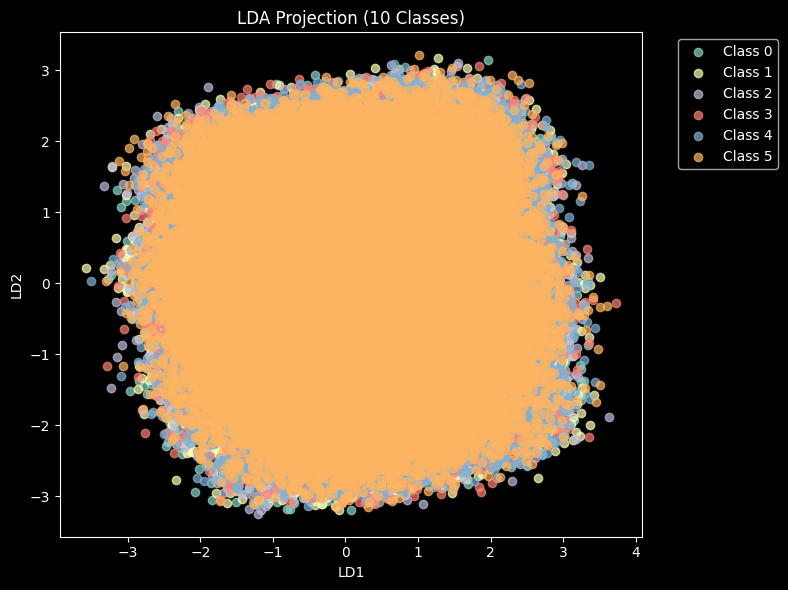

In [ ]:
plt.figure(figsize=(8, 6))

for c in np.unique(target):
    plt.scatter(
        X_train_lda[target == c, 0],
        X_train_lda[target == c, 1],
        label=f"Class {c}",
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (10 Classes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
final_df_after_lda = pd.DataFrame(X_train_lda , columns = [f"LD{i+1}" for i in range(n_components)])
final_df_after_lda['target'] = target

In [ ]:
final_df_after_lda.head()

,LD1,LD2,LD3,LD4,LD5,target
0,-0.309072,-1.479029,-1.949338,-0.477222,-0.078907,3
1,-0.332794,0.110207,-0.197094,0.530115,-0.123600,4
2,0.538180,0.362319,2.269336,-1.966463,1.355498,3
3,0.207335,-0.664792,-0.059544,1.710098,0.426922,3
4,0.716022,-0.186572,-0.008480,1.366456,-0.062727,5


### **Solve Imbalanced data**

In [ ]:
final_df_after_lda['target'].value_counts()

,count
target,
4,101286
3,99228
0,97320
1,96975
5,95794
2,95296


`we make all classes < 1000`
`but Now we will use class_weight='balanced' in our Model`

### **Final Preprocessing (Result)**

In [ ]:
final_df.head()

,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,target
0,2.705517,1.043451,-2.325842,-0.265080,-0.153016,0.576329,-0.914319,0.229731,-0.363052,6
1,1.183871,0.294492,1.311305,-1.922766,-0.699789,-0.870149,-0.954513,0.794721,-0.280757,6
2,-4.076827,1.455201,1.609056,1.240158,1.130050,-0.106601,-1.486629,0.827093,0.553869,9
3,-0.236668,-0.736233,0.459595,1.318138,-0.973054,-0.386289,-0.832243,1.126196,1.745144,0
4,2.286663,0.289125,0.348703,-1.414179,-0.040101,-0.402979,-1.298652,1.700397,-1.148789,6


In [ ]:
# from google.colab import files

# # Save the DataFrame to a CSV file
# final_df.to_csv('final_processed_data(crop_remmendation).csv', index=False)

# # Download the file
# files.download('final_processed_data(crop_remmendation).csv')

# **Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

In [ ]:
numerical_columns = [
    col for col in features_after_FS.columns
    if features_after_FS[col].nunique() >= 10
]

Categorical_columns = [
    col for col in features_after_FS.columns
    if features_after_FS[col].nunique() <= 10
]

In [ ]:
def Encode(df_origin : pd.DataFrame) -> pd.DataFrame :
  "Take Original Data and make one hot Encode for numirc columns"


  loaded_encoder = joblib.load(ONE_HOT_ENCODE)

  df_num = df_origin.select_dtypes(include = ['int64' , 'float64' ])
  df_cat = df_origin.select_dtypes(include = ['object'])

  df_cat_encoder_array = loaded_encoder.transform(df_cat)
  df_encoder_dataFrame = pd.DataFrame(df_cat_encoder_array , columns = loaded_encoder.get_feature_names_out(df_cat.columns))

  x = pd.concat(
      [df_num, df_encoder_dataFrame],
      axis=1
  )
  return x

In [ ]:
Encoder = FunctionTransformer(Encode, validate=False)

# FeaturesExtraction = FunctionTransformer(feature_extraction, validate=False) #feature_extraction function

FeaturesSelection  = FunctionTransformer(feature_selection, validate=False) # you should make feature_selection function

In [ ]:
Transformer = ColumnTransformer(transformers=[
    ('PowerTransform' , PowerTransformer(method='yeo-johnson'),numerical_columns),
],remainder="passthrough" )

In [ ]:
pipe_with_lda = Pipeline(steps = [
    ('Encoding' , Encoder),
    ('FeaturesSelect' , FeaturesSelection),
    ('PowerTransform' , Transformer),
    ('LDA' , lda)
])

pipe_without_lda = Pipeline(steps = [
    ('Encoding' , Encoder),
    ('FeaturesSelect' , FeaturesSelection),
    ('PowerTransform' , Transformer),
])

In [ ]:
df_test.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region'],
      dtype='object')

In [ ]:
y = df_train['Crop_Type' ]
x = df_train.drop('Crop_Type' , axis = 1)

df_without_lda = pipe_without_lda.fit(x , y )
df_with_lda = pipe_with_lda.fit(x , y )
pipe_with_lda

Pipeline(steps=[('Encoding',
                 FunctionTransformer(func=<function Encode at 0x7b79171aa200>)),
                ('FeaturesSelect',
                 FunctionTransformer(func=<function feature_selection at 0x7b791db0c720>)),
                ('PowerTransform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('PowerTransform',
                                                  PowerTransformer(),
                                                  ['Previous_Irrigation_mm',
                                                   'Humidity', 'Soil_Moisture',
                                                   'Wind_Speed_kmh',
                                                   'Temperature_C', 'Soil_pH',
                                                   'Electrical_Conductivity',
                                                   'Field_Area_hectare',
                                                   'Organic_Carbon',
                                                   'Sunlight_Hours'])])),
                ('LDA', LinearDiscriminantAnalysis(n_components=5))])

In [ ]:
pipe_without_lda

Pipeline(steps=[('Encoding',
                 FunctionTransformer(func=<function Encode at 0x7b79171aa200>)),
                ('FeaturesSelect',
                 FunctionTransformer(func=<function feature_selection at 0x7b791db0c720>)),
                ('PowerTransform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('PowerTransform',
                                                  PowerTransformer(),
                                                  ['Previous_Irrigation_mm',
                                                   'Humidity', 'Soil_Moisture',
                                                   'Wind_Speed_kmh',
                                                   'Temperature_C', 'Soil_pH',
                                                   'Electrical_Conductivity',
                                                   'Field_Area_hectare',
                                                   'Organic_Carbon',
                                                   'Sunlight_Hours'])]))])

### **Save pipeline**

In [ ]:
import joblib
from google.colab import files


pipeline_with_lda_filename = 'Crop_Recommendation_Pipeline_with_lda(Preprocessing).joblib'

joblib.dump(pipe_with_lda, pipeline_with_lda_filename)
print(f"Pipeline saved successfully to {pipeline_with_lda_filename}")


# Download the saved pipeline file
files.download(pipeline_with_lda_filename)

Pipeline saved successfully to Crop_Recommendation_Pipeline_with_lda(Preprocessing).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pipeline_without_lda_filename = 'Crop_Recommendation_Pipeline_without_lda(Preprocessing).joblib'

joblib.dump(pipe_without_lda, pipeline_without_lda_filename)
print(f"Pipeline saved successfully to {pipeline_without_lda_filename}")


# Download the saved pipeline file
files.download(pipeline_without_lda_filename)

Pipeline saved successfully to Crop_Recommendation_Pipeline_without_lda(Preprocessing).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Test Pipleline**

`With lda`

In [ ]:
input = df_train.drop('Crop_Type' , axis = 1)
input = pipe_with_lda.transform(input)
pd.DataFrame(input).head()

,0,1,2,3,4
0,-0.309072,-1.479029,-1.949338,-0.477222,-0.078907
1,-0.332794,0.110207,-0.197094,0.530115,-0.123600
2,0.538180,0.362319,2.269336,-1.966463,1.355498
3,0.207335,-0.664792,-0.059544,1.710098,0.426922
4,0.716022,-0.186572,-0.008480,1.366456,-0.062727


In [ ]:
final_df_after_lda.head()

,LD1,LD2,LD3,LD4,LD5,target
0,-0.309072,-1.479029,-1.949338,-0.477222,-0.078907,3
1,-0.332794,0.110207,-0.197094,0.530115,-0.123600,4
2,0.538180,0.362319,2.269336,-1.966463,1.355498,3
3,0.207335,-0.664792,-0.059544,1.710098,0.426922,3
4,0.716022,-0.186572,-0.008480,1.366456,-0.062727,5


`WithOut Lda`

In [ ]:
final_df_after_lda['target'].value_counts()

,count
target,
4,101286
3,99228
0,97320
1,96975
5,95794
2,95296


In [ ]:
input = df_train.drop('Crop_Type' , axis = 1)
input = pipe_without_lda.transform(input)
pd.DataFrame(input).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-1.429411,1.644919,-0.706201,1.031887,-1.724789,-1.354203,0.931615,1.052919,-0.144374,1.583242,0.0,0.0,0.0,1.0
1,0.387102,0.282026,0.644304,0.450627,0.605245,-0.475443,-0.481104,-0.097655,-0.484413,1.308104,0.0,0.0,0.0,0.0
2,0.368374,-1.524847,-1.104903,1.434654,0.999893,-0.633184,-0.761787,-0.330689,0.576751,0.682567,1.0,1.0,1.0,0.0
3,1.119580,0.421676,0.408464,1.326789,0.328305,-0.319444,0.526335,1.122969,1.692075,-1.272038,0.0,0.0,0.0,0.0
4,1.523318,0.349159,0.719448,0.808257,-0.229145,-0.884720,-0.784707,0.474338,0.929844,-0.730377,0.0,0.0,0.0,0.0


# **Finish**